### Implementation of video 2:
### "Building makemore Part 2: MLP"
*(https://youtu.be/TCH_1BHY58I?si=K-3LdgqGDGu-z3Be)*

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import mlflow
import mlflow.pytorch
import os

root_project_path = os.path.abspath("..")
database_path = f"sqlite:///{os.path.join(root_project_path, 'mlflow.db')}"
mlflow.set_tracking_uri(database_path)


In [3]:
mlflow.set_experiment("makemore_file2_mlp")


<Experiment: artifact_location=('file:c:/Users/yashs/Documents/Lambton-sem3/Neural '
 'Network/build_makemore/notebook/mlruns/2'), creation_time=1776639444385, experiment_id='2', last_update_time=1776639444385, lifecycle_stage='active', name='makemore_file2_mlp', tags={}, trace_location=None, workspace='default'>

In [4]:
words = open('../data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [6]:
characters = sorted(list(set(''.join(words))))
s_to_i = {s:i+1 for i,s in enumerate(characters)}
s_to_i['.'] = 0
i_to_s = {i:s for s,i in s_to_i.items()}
print(i_to_s)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
# build dataset

block_size = 3
X, Y = [], []
# for w in words[:5]:
for w in words:

    # print(w)
    context = [0] * block_size
    for chr in w + '.':
        ix = s_to_i[chr]
        X.append(context)
        Y.append(ix)
        # print(''.join(i_to_s[i] for i in context), '---->', i_to_s[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [8]:
X.shape, X.dtype, Y.shape, Y.dtype

# output for first 5 words was:
# (torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

Train split, dev/validation split, test split

In [9]:
# converting above code to a function for later use
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    # for w in words[:5]:
    for w in words:

        # print(w)
        context = [0] * block_size
        for chr in w + '.':
            ix = s_to_i[chr]
            X.append(context)
            Y.append(ix)
            # print(''.join(i_to_s[i] for i in context), '---->', i_to_s[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

# shuffling
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# 80% training, 10% dev, 10% test
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [10]:
C = torch.randn((27, 2))

onehot encoding example

In [11]:
# C[5]

In [12]:
# F.one_hot(torch.tensor([5]), num_classes=27)

resuming with makemore

In [13]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [14]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [15]:
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)
h

tensor([[-0.9037, -0.9366,  1.0000,  ..., -0.9894, -0.5327, -0.9297],
        [ 0.9817, -0.9983,  0.8864,  ...,  0.6526, -0.6102,  0.1006],
        [ 0.9997, -0.9861,  0.2394,  ..., -0.4835,  0.9215,  0.9840],
        ...,
        [-0.7747, -0.9978,  1.0000,  ..., -0.9988,  0.7832, -0.9751],
        [-0.6483, -0.9994,  1.0000,  ..., -0.9895,  0.3677, -0.9814],
        [-0.0461, -0.9904,  1.0000,  ..., -0.9988,  0.3819, -0.9729]])

In [16]:
h.shape

torch.Size([228146, 100])

In [17]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [18]:
logits = h @ W2 + b2
logits.shape

torch.Size([228146, 27])

In [19]:
count = logits.exp()

In [20]:
prob = count / count.sum(1, keepdim=True)

prob.shape

torch.Size([228146, 27])

In [21]:
# loss = -prob[torch.arange(32), Y].log().mean()

# loss

 Since we now know how to calculate 'loss', so we use that logic

In [22]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [23]:
# Initialize the parameters

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [24]:
sum(p.nelement() for p in parameters)

11897

In [25]:
"""
By default, tensors created via torch.randn() do not track gradients or participate in the computation graph. 
This means loss.backward() can't propagate gradients back to them, leading to an error:
"RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn"
"""

for p in parameters:
    p.requires_grad = True

In [26]:
# determining learning rate exponent
lre = torch.linspace(-3, 0, steps=1000)

lrs = 10**lre
# lrs

In [27]:
# determine lre: track stats
lri= []
lossi = []
stepi = []


In [28]:
run_id = None
with mlflow.start_run() as run:
    run_id = run.info.run_id

    max_steps = 200000
    mlflow.log_param("max_steps", max_steps)
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("block_size", block_size)
    mlflow.log_param("embedding_dim", 10)
    mlflow.log_param("hidden_units", 200)
    mlflow.log_param("lr_initial", 0.1)
    mlflow.log_param("lr_decayed", 0.01)
    mlflow.log_param("lr_decay_step", 100000)
    mlflow.log_param("n_parameters", sum(p.nelement() for p in parameters))

    for i in range(max_steps):

        # mini-batch construct
        ix = torch.randint(0, Xtr.shape[0], (32,))

        # forward pass
        emb = C[Xtr[ix]] # (32, 3, 2)
        h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
        logits = h @ W2 + b2 # (32, 27)

        # counts = logits.exp()
        # prob = counts / counts.sum(1, keepdim=True)
        # loss = -prob[torch.arange(32), Y].log().mean()

        # replace above logic (3 lines) with cross_entropy
        loss = F.cross_entropy(logits, Ytr[ix])
        # print(loss.item())

        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        #update
        # lr = lrs[i]
        lr = 0.1 if i < 100000 else 0.01

        for p in parameters:
            p.data += -lr * p.grad

        # # determine lre: track stats
        # lri.append(lre[i])
        lossi.append(loss.log10().item())
        stepi.append(i)
        mlflow.log_metric("loss", loss.item(), step=i)

    # print(loss.item())

    # determine lre:plotting the learning rate exponent vs loss
    # plt.plot(lri, lossi)
    # plt.plot(stepi, lossi)

    os.makedirs("../weights", exist_ok=True)
    torch.save({
        "C": C, "W1": W1, "b1": b1, "W2": W2, "b2": b2,
    }, "../weights/file2_mlp.pt")
    mlflow.log_artifact("../weights/file2_mlp.pt")


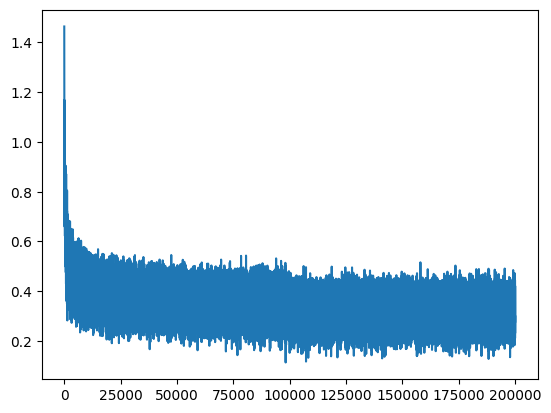

In [29]:
mlflow.start_run(run_id=run_id)

os.makedirs("../plots", exist_ok=True)
plt.plot(stepi, lossi)
plt.savefig("../plots/file2_mlp_loss.png")

mlflow.log_artifact("../plots/file2_mlp_loss.png")


For entire dataset:
learning rate = 0.1, we get: loss ~ 2.487
learning rate = 0.01, we get: loss ~ 2.57

In [30]:
# training dataset
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1183, grad_fn=<NllLossBackward0>)

In [31]:
# validation dataset
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1640, grad_fn=<NllLossBackward0>)

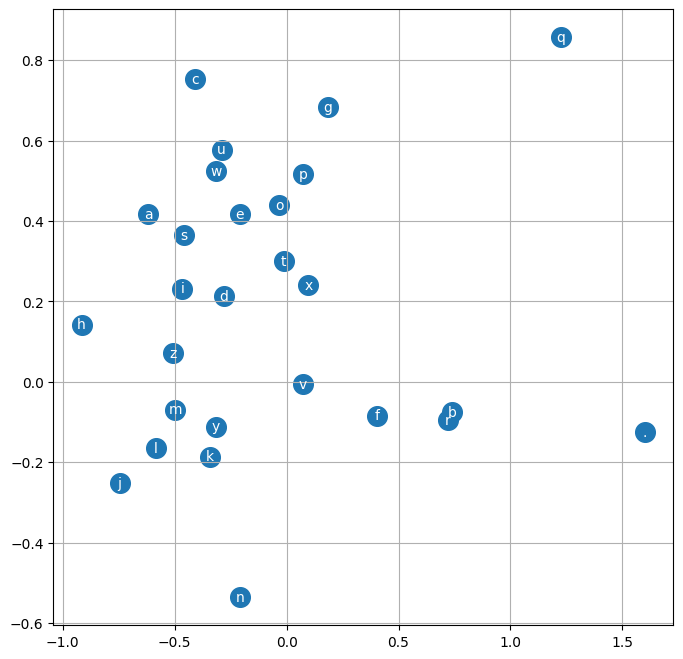

In [32]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range (C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), i_to_s[i], ha='center', va='center', color='white')
plt.grid('minor')

In [34]:
mlflow.end_run() 

In [35]:
# Reusing the same run to log the generated samples
mlflow.start_run(run_id=run_id)

# sample from the model
g = torch.Generator().manual_seed(2147483647)

for k in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    sample_text = ''.join(i_to_s[i] for i in out)
    print(sample_text)
    mlflow.log_text(sample_text, f"sample_{k}.txt")

mlflow.end_run()


dex.
mariah.
makila.
kayden.
maimitta.
nylandrik.
tar.
samiyah.
javaryiot.
shid.
jen.
kau.
keyted.
jen.
emithsade.
enka.
graylynns.
milliven.
tahlyn.
dasdra.
